#Collection, Loading and Analysis of FRED Dataset.

## Step One: Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import date
import pandas_datareader.data as web  ##Importing data fetching utility

## Step Two: Loading and analysis of GDP dataset.

In [ ]:
## Setting start and end date for extraction.

start_dt = date.fromisoformat('1999-01-01')
end_dt = date.today()


gdp_fred_data = web.get_data_fred('GDPC1', start=start_dt, end=end_dt) ## GDPC1 API used for extracting quarterly GDP values.

In [ ]:
gdp_fred_data

,GDPC1
DATE,
1999-01-01,13315.597
1999-04-01,13426.748
1999-07-01,13604.771
1999-10-01,13827.980
2000-01-01,13878.147
...,...
2024-07-01,23478.570
2024-10-01,23586.542
2025-01-01,23548.210


### There are total 107 rows from 1999 to 2025 as there are quaterly data.

In [ ]:
## Finding yearly actual GDP percenatge.

gdp_rolling_avg = gdp_fred_data['GDPC1'].rolling(4).mean() ## Calculating average of previous four quarter GDP value.
yoy_gdp_change = round(gdp_rolling_avg.pct_change(4)*100,2)  ## Calculating GDP growth from previous year (change from previous fourth GDP)
gdp_fred_data['yoy_gdp_%']=yoy_gdp_change
gdp_fred_data

,GDPC1,yoy_gdp_%
DATE,,
1999-01-01,13315.597,NaN
1999-04-01,13426.748,NaN
1999-07-01,13604.771,NaN
1999-10-01,13827.980,NaN
2000-01-01,13878.147,NaN
...,...,...
2024-07-01,23478.570,3.04
2024-10-01,23586.542,2.79
2025-01-01,23548.210,2.58


In [ ]:
## Keeping records from Oct 2000 to 2025 by removing NAN values.
gdp_fred_data.dropna(inplace=True)
gdp_fred_data


,GDPC1,yoy_gdp_%
DATE,,
2000-10-01,14229.765,4.08
2001-01-01,14183.120,3.57
2001-04-01,14271.694,2.50
2001-07-01,14214.516,1.64
2001-10-01,14253.574,0.96
...,...,...
2024-07-01,23478.570,3.04
2024-10-01,23586.542,2.79
2025-01-01,23548.210,2.58


## Visualisation of GDP growth

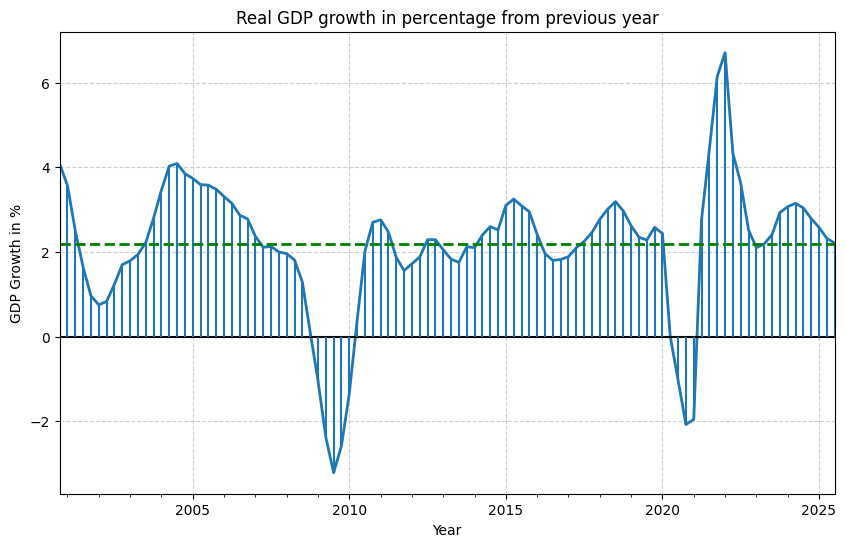

In [ ]:
## Plot of GDP growth.

fig = gdp_fred_data['yoy_gdp_%'].plot(linewidth=2, figsize=(10,6), title='Real GDP growth in percentage from previous year')
fig.grid(True, linestyle='--', alpha=0.6)
fig.set_xlabel('Year')
fig.set_ylabel('GDP Growth in %')
fig.axhline(y=0, color='black', linewidth=1.5)

fig.vlines(
    x=gdp_fred_data.index,
    ymin=0,
    ymax=gdp_fred_data['yoy_gdp_%'],
    linewidth=1.5
)
fig.axhline(
    y=gdp_fred_data['yoy_gdp_%'].mean(),
    lw=2,
    ls='--',
    color='green',
    label='Average of annual growth from 2000-2025')
plt.show()


## Step Three: Loading and analysis of Employment and Unemployment rate.

In [ ]:
## Setting start and end date for extraction.

start_dt = date.fromisoformat('2000-01-01')
end_dt = date.today()

## Loading of dataset.

poppulation_data = web.get_data_fred(['CNP16OV', 'CLF16OV', 'CE16OV'], start_dt, end_dt)

##### API 'CNP16OV' is used for extraction of poppulation level data consisting of people 16 years and older age and are not on active duty in Armed forces.<br>
##### API 'CLF16OV' used for extraction of population data of Labour force group that are 16 years of age and older and are either working or actively looking for work.<br>
##### API 'CE16OV' used for extraction of population data of employed group that are 16 years of age and older and are actively working .


In [ ]:
## Rename columns for better interpretation of columns.

poppulation_data.rename(columns={'CNP16OV':'Civilian_Population_16+', 'CLF16OV':'Total_Labor_Force', 'CE16OV':'Employed_Population'}, inplace=True)
poppulation_data

,Civilian_Population_16+,Total_Labor_Force,Employed_Population
DATE,,,
2000-01-01,211410.0,142267.0,136559.0
2000-02-01,211576.0,142456.0,136598.0
2000-03-01,211772.0,142434.0,136701.0
2000-04-01,212018.0,142751.0,137270.0
2000-05-01,212242.0,142388.0,136630.0
...,...,...,...
2025-08-01,274001.0,170750.0,163370.0
2025-09-01,274226.0,171261.0,163656.0
2025-10-01,NaN,NaN,NaN


#### Employment dataset contains monthly data and there are total 312 rows from 2000 till 2025.

In [ ]:
## Checking for missing values

print(poppulation_data.isna().sum()) ## There is only one row having null values.

## Removing the row having null value

poppulation_data.dropna(inplace=True)
poppulation_data.isna().sum()  ## Null values are removed

Civilian_Population_16+    1
Total_Labor_Force          1
Employed_Population        1
dtype: int64


,0
Civilian_Population_16+,0
Total_Labor_Force,0
Employed_Population,0


In [ ]:
poppulation_data.shape ## Now we have total 311 rows

(311, 3)

In [ ]:
## Calculating Employment and Unemployment rate and Participation rate. Participation rate indicates percentage of working-age population that is either employed or lookimg for job.

## Participation Rate  = Total Labor Force / Total Civilian Population
## Employment rate = Employed Population / Total Civilian Population
## Unemployment rate = (Total Labor Force-Employed Population) / Total Labor Force

poppulation_data['Participation_Rate_%'] = round(poppulation_data['Total_Labor_Force']/poppulation_data['Civilian_Population_16+']*100,2)
poppulation_data['Employment_Rate_%'] = round(poppulation_data['Employed_Population']/poppulation_data['Civilian_Population_16+']*100,2)
poppulation_data['Unemployment_Rate_%'] = round(((poppulation_data['Total_Labor_Force']-poppulation_data['Employed_Population'])\
                                                 /poppulation_data['Total_Labor_Force'])*100,2)

poppulation_data.head(20)

,Civilian_Population_16+,Total_Labor_Force,Employed_Population,Participation_Rate_%,Employment_Rate_%,Unemployment_Rate_%
DATE,,,,,,
2000-01-01,211410.0,142267.0,136559.0,67.29,64.59,4.01
2000-02-01,211576.0,142456.0,136598.0,67.33,64.56,4.11
2000-03-01,211772.0,142434.0,136701.0,67.26,64.55,4.03
2000-04-01,212018.0,142751.0,137270.0,67.33,64.74,3.84
2000-05-01,212242.0,142388.0,136630.0,67.09,64.37,4.04
2000-06-01,212466.0,142591.0,136940.0,67.11,64.45,3.96
2000-07-01,212677.0,142278.0,136531.0,66.90,64.20,4.04
2000-08-01,212916.0,142514.0,136662.0,66.93,64.19,4.11
2000-09-01,213163.0,142518.0,136893.0,66.86,64.22,3.95


### Visualisation of Employment and Unemploymemt rate.

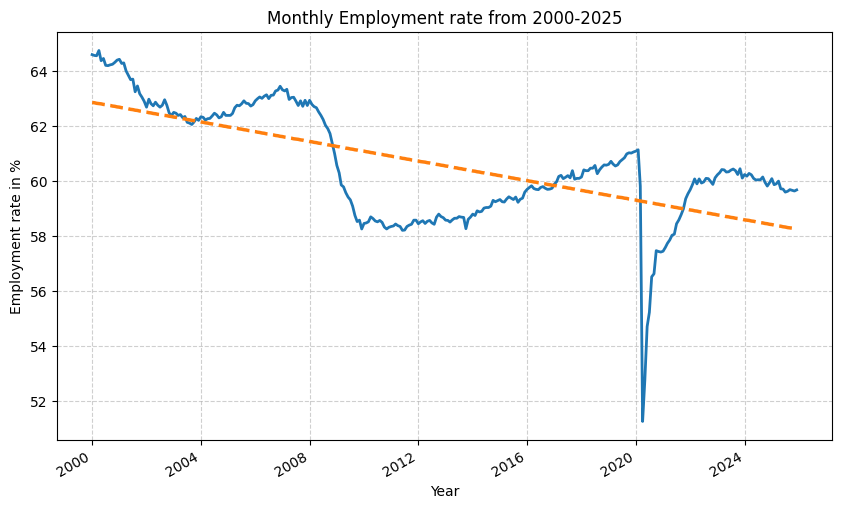

In [ ]:
## To plot employment rate for analysis.

fig = poppulation_data['Employment_Rate_%'].plot(linewidth=2, figsize=(10,6), title='Monthly Employment rate from 2000-2025')
fig.grid(True, linestyle='--', alpha=0.6)
fig.set_xlabel('Year')
fig.set_ylabel('Employment rate in %')

## To add trend in graph as liner straight line to understand the rise/fall in rate from 2000.

x=np.arange(len(poppulation_data.index))
y=poppulation_data['Employment_Rate_%'].values
coef=np.polyfit(x,y,1)    ## polyfit() function is to find best value of m(slope) and c(intercept) given value of x and y.
trend=[]
for i in x:
  trend.append(float(round(coef[0]*i+coef[1],2)))   ## first element in 'coef' is value of m(slope of line) and /
                                                    ##second element in 'coef' is value of c(intercept of linbe).
fig.plot(poppulation_data.index,trend, linestyle='--', linewidth=2.5, label='Linear Trend')
plt.show()

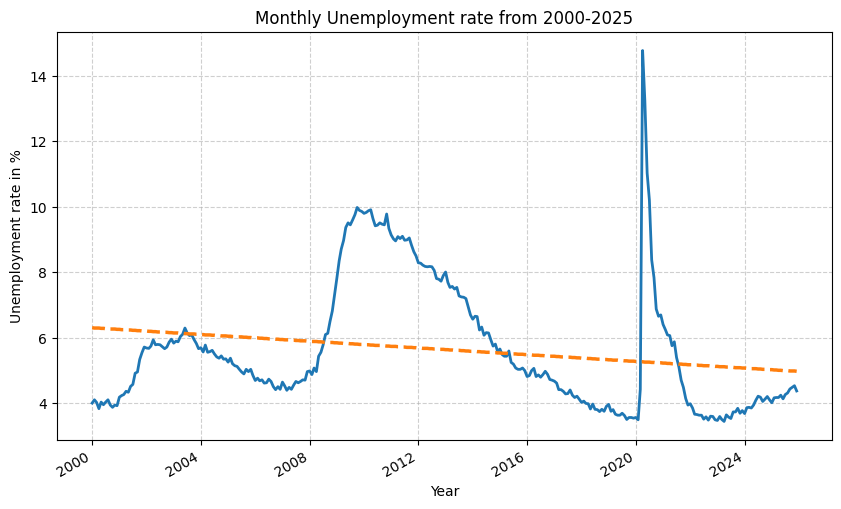

In [ ]:
## To plot unemployment rate for analysis.

fig = poppulation_data['Unemployment_Rate_%'].plot(linewidth=2, figsize=(10,6), title='Monthly Unemployment rate from 2000-2025')
fig.grid(True, linestyle='--', alpha=0.6)
fig.set_xlabel('Year')
fig.set_ylabel('Unemployment rate in %')

## To add trend in graph as liner straight line to understand the rise/fall in rate from 2000.

x=np.arange(len(poppulation_data.index))
y=poppulation_data['Unemployment_Rate_%'].values
coef=np.polyfit(x,y,1)    ## polyfit() function is to find best value of m(slope) and c(intercept) given value of x and y.
trend=[]
for i in x:
  trend.append(float(round(coef[0]*i+coef[1],2)))   ## first element in 'coef' is value of m(slope of line) and /
                                                    ##second element in 'coef' is value of c(intercept of linbe).
fig.plot(poppulation_data.index,trend, linestyle='--', linewidth=2.5, label='Linear Trend')
plt.show()

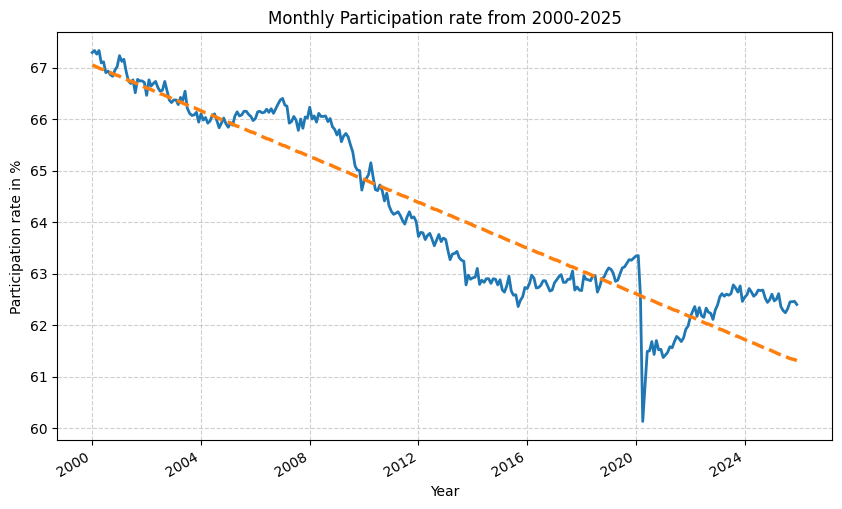

In [ ]:
## To plot participation rate for analysis.

fig = poppulation_data['Participation_Rate_%'].plot(linewidth=2, figsize=(10,6), title='Monthly Participation rate from 2000-2025')
fig.grid(True, linestyle='--', alpha=0.6)
fig.set_xlabel('Year')
fig.set_ylabel('Participation rate in %')

## To add trend in graph as liner straight line to understand the rise/fall in rate from 2000.

x=np.arange(len(poppulation_data.index))
y=poppulation_data['Participation_Rate_%'].values
coef=np.polyfit(x,y,1)    ## polyfit() function is to find best value of m(slope) and c(intercept) given value of x and y.
trend=[]
for i in x:
  trend.append(float(round(coef[0]*i+coef[1],2)))   ## first element in 'coef' is value of m(slope of line) and /
                                                    ##second element in 'coef' is value of c(intercept of linbe).
fig.plot(poppulation_data.index,trend, linestyle='--', linewidth=2.5, label='Linear Trend')
plt.show()

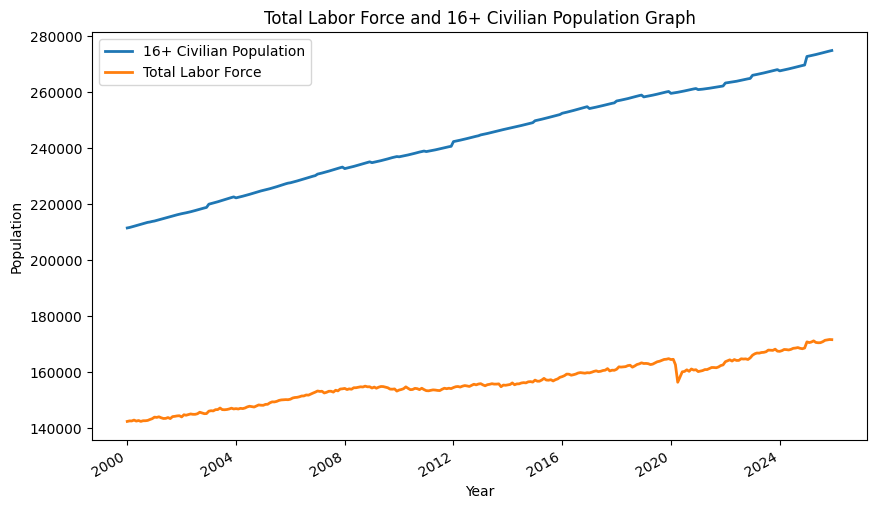

In [ ]:
## Plot of Labor Force and Civil institutional Population agend 16+ to understand the sharp decrease in participation rate.

fig = poppulation_data['Civilian_Population_16+'].plot(linewidth=2, figsize=(10,6))
fig.grid(True, linestyle='--', alpha=0.6)
fig = poppulation_data['Total_Labor_Force'].plot(linewidth=2, figsize=(10,6), title='Total Labor Force and 16+ Civilian Population Graph')
fig.set_xlabel('Year')
fig.set_ylabel('Population')
fig.legend(['16+ Civilian Population', 'Total Labor Force'])
plt.show()

### We can see that civilian population increases sharply as compared to Labor force population graph that increases slowly and hence it is evident that participant rate decreases sharply.

### One of the possible factor contributing to slow increase in labor force population is due to ageing population that is more people enters retirement age and workers not working anymore and not looking for jobs or leave labor force, some  working groups populatoion look for higher eductaion and opt for full time eductaion thus leaving working group.

## Step Four: Loading and analysis of Breakeven Inflation rate.

In [ ]:
## Setting start and end date for extraction.

start_dt = date.fromisoformat('2000-01-01')
end_dt = date.today()

## Loading of dataset.

inflation_data = web.get_data_fred(['T5YIE', 'T10YIE',], start_dt, end_dt)

## Rename columns for better interpretation of columns.

inflation_data.rename(columns={'T5YIE':'Breakdown_Inflation_5_year', 'T10YIE':'Breakdown_Inflation_10_year'}, inplace=True)
inflation_data

,Breakdown_Inflation_5_year,Breakdown_Inflation_10_year
DATE,,
2003-01-02,1.30,1.64
2003-01-03,1.28,1.62
2003-01-06,1.31,1.63
2003-01-07,1.28,1.62
2003-01-08,1.33,1.71
...,...,...
2026-01-28,2.50,2.36
2026-01-29,2.52,2.35
2026-01-30,2.53,2.36


#### Inflation rate extracted is daily expected rate. There are 6023 rows.

In [ ]:
## Checking for missing values

print(inflation_data.isna().sum())


Breakdown_Inflation_5_year     249
Breakdown_Inflation_10_year    249
dtype: int64


#### 4% of total records are null values.

In [ ]:
##Analysing missing records.

inflation_data[inflation_data['Breakdown_Inflation_5_year'].isna()].index.values

array(['2003-01-20T00:00:00.000000000', '2003-02-17T00:00:00.000000000',
       '2003-04-18T00:00:00.000000000', '2003-05-26T00:00:00.000000000',
       '2003-07-04T00:00:00.000000000', '2003-09-01T00:00:00.000000000',
       '2003-10-13T00:00:00.000000000', '2003-11-11T00:00:00.000000000',
       '2003-11-27T00:00:00.000000000', '2003-12-25T00:00:00.000000000',
       '2004-01-01T00:00:00.000000000', '2004-01-19T00:00:00.000000000',
       '2004-02-16T00:00:00.000000000', '2004-04-09T00:00:00.000000000',
       '2004-05-31T00:00:00.000000000', '2004-06-11T00:00:00.000000000',
       '2004-07-05T00:00:00.000000000', '2004-09-06T00:00:00.000000000',
       '2004-10-11T00:00:00.000000000', '2004-11-11T00:00:00.000000000',
       '2004-11-25T00:00:00.000000000', '2004-12-24T00:00:00.000000000',
       '2005-01-17T00:00:00.000000000', '2005-02-21T00:00:00.000000000',
       '2005-03-25T00:00:00.000000000', '2005-05-30T00:00:00.000000000',
       '2005-07-04T00:00:00.000000000', '2005-09-05

In [ ]:
## Removing the row having null value as they are uniformly spread across all year and it is safe to remove these considering the % of missing values which is 4% and is very low.

inflation_data.dropna(inplace=True)
inflation_data.isna().sum()  ## Null values are removed

,0
Breakdown_Inflation_5_year,0
Breakdown_Inflation_10_year,0


In [ ]:
inflation_data.shape

(5775, 2)


## Total records are 5774 after removing null values from infaltion rate dataset.

### Visualisation of Inflation rate.

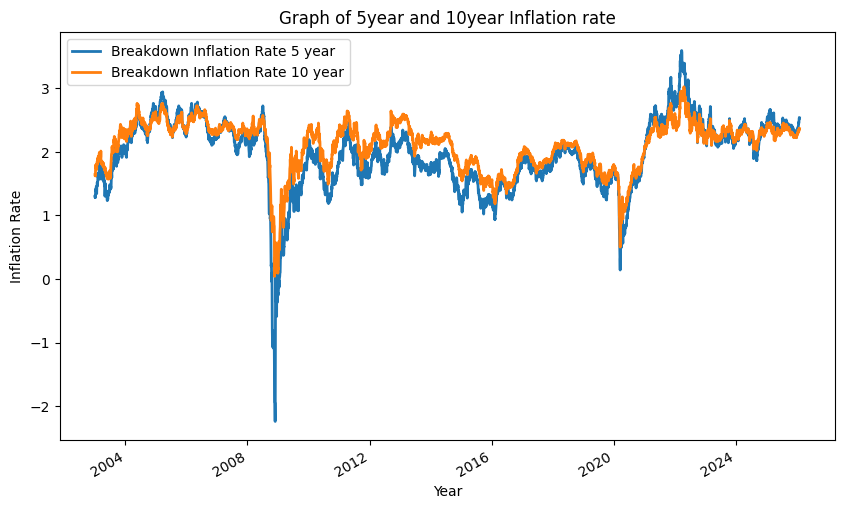

In [ ]:
## To plot 5 year Breakeven inflation rate (expected inflation rate in next 5 year) and 10 year Breakeven inflation rate (expected inflation rate in next 10 year).

fig = inflation_data['Breakdown_Inflation_5_year'].plot(linewidth=2, figsize=(10,6))
fig = inflation_data['Breakdown_Inflation_10_year'].plot(linewidth=2, figsize=(10,6), title='Graph of 5year and 10year Inflation rate')
fig.set_xlabel('Year')
fig.set_ylabel('Inflation Rate')
fig.legend(['Breakdown Inflation Rate 5 year', 'Breakdown Inflation Rate 10 year'])
plt.show()


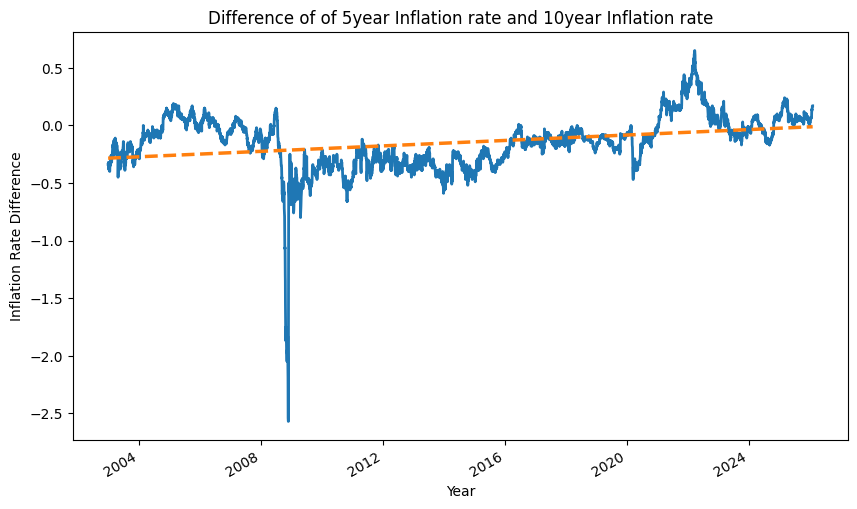

In [ ]:
## To plot differences of 5 year Breakeven inflation rate and 10 year Breakeven inflation rate to analyse the pattern.

fig =(inflation_data['Breakdown_Inflation_5_year']-inflation_data['Breakdown_Inflation_10_year']).plot(linewidth=2, figsize=(10,6),\
                                                                title='Difference of of 5year Inflation rate and 10year Inflation rate')
fig.set_xlabel('Year')
fig.set_ylabel('Inflation Rate Difference')

## To add trend in graph as liner straight line to understand the rise/fall/stable in inflation differences.

x=np.arange(len(inflation_data.index))
y=(inflation_data['Breakdown_Inflation_5_year']-inflation_data['Breakdown_Inflation_10_year']).values
coef=np.polyfit(x,y,1)    ## polyfit() function is to find best value of m(slope) and c(intercept) given value of x and y.
trend=coef[0]*x + coef[1] ## first element in 'coef' is value of m(slope of line) and second element in 'coef' is value of c(intercept of linbe).
fig.plot(inflation_data.index,trend, linestyle='--', linewidth=2.5, label='Linear Trend')
plt.show()

### We can see that slope is gradually increasing which indicates expected short term inflation rate is higher than expected long term inflation rate and thus market assumes that increase in inflation rate is short term and in long run it is expected to be stable around with central bank target rate.

## Step Three: Loading and analysis of Fed Funds Rate.

In [ ]:
## Setting start and end date for extraction.

start_dt = date.fromisoformat('2024-01-01')
# end_dt = date.today()
end_dt = date.fromisoformat('2025-01-01')
## Loading of dataset.

fed_fund_data = web.get_data_fred(['FEDFUNDS'], start_dt, end_dt)

## Rename columns for better interpretation of columns.

fed_fund_data.rename(columns={'FEDFUNDS':'Federal_Funds_Rate_%'}, inplace=True)
fed_fund_data.sort_index()
fed_fund_data

,Federal_Funds_Rate_%
DATE,
2024-01-01,5.33
2024-02-01,5.33
2024-03-01,5.33
2024-04-01,5.33
2024-05-01,5.33
2024-06-01,5.33
2024-07-01,5.33
2024-08-01,5.33
2024-09-01,5.13


In [ ]:
## Checking for missing values

print(fed_fund_data.isna().sum())


Federal_Funds_Rate_%    0
dtype: int64


#### There are no missing values.

In [ ]:
fed_fund_data.shape

(313, 1)

##### It has monthly data from 2000 till date and there are total 313 rows.

### Visualisation of Federal Funds rate.

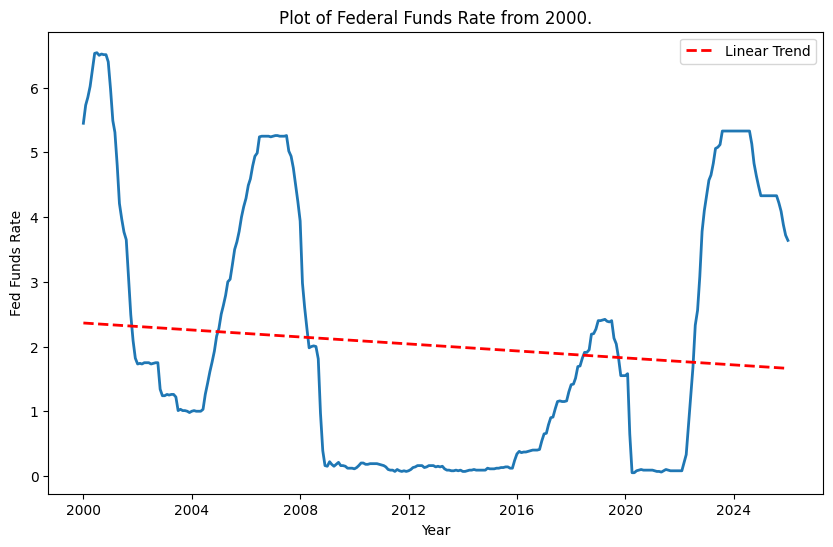

In [ ]:
## To plot effective Federal Funds rate.

plt.figure(figsize=(10,6))
plt.plot(fed_fund_data.index, fed_fund_data['Federal_Funds_Rate_%'], linewidth=2)
plt.xlabel('Year')
plt.ylabel('Fed Funds Rate')
plt.title('Plot of Federal Funds Rate from 2000.')

## To add trend in graph as liner straight line to understand the rise/fall/stable in funds rate.
x = np.arange(len(fed_fund_data))
y = fed_fund_data['Federal_Funds_Rate_%'].values
coef = np.polyfit(x, y, 1)   ## polyfit() function is to find best value of m(slope) and c(intercept) given value of x and y.
trend_fund = coef[0]*x + coef[1]   ## first element in 'coef' is value of m(slope of line) and second element in 'coef' is value of c(intercept of line)

plt.plot(fed_fund_data.index, trend_fund, linestyle='--', linewidth=2, label='Linear Trend', color='red')

plt.legend()
plt.show()

### Federeal Funds rate pattern shows strong cyclical behaviour from 2000 with a liner trend of slightly negative slope. The Rate had been highest in July 2000 at 6.5% rate and dropped to 1% in 2004. There has been a prolonged duration of reduced interest rate from Oct 2008 till 2014 at approximately 0.08% throughout, indicating recovery of economy post financial crisis, and a similar pattern is also observed from 2020 till mid-year 2022 due to the pandemic. The rate then increased sharply to 5.3% in 2024. This cyclical beghaviour signifies Federal policy measures to reduce rates during economic instability and pandemic situations for growth, and increase of rates during economic expansion to restrict inflation.